# 10 — Build Analytical Base Tables (ABT)
**Datathon 2026 | The Gridbreakers | Phase 2 (L2)**

**Mục tiêu:** Áp dụng cleaning rules → build 3 ABT leakage-safe cho phân tích & modelling.

| ABT | Grain | Dùng cho |
|---|---|---|
| `abt_daily.parquet` | 1 row / ngày (2012-07-04 → 2024-07-01) | Part 3 forecasting + Story 2 |
| `abt_orders_enriched.parquet` | 1 row / order_item (5-way join) | Part 2 Stories 1,4,6,7 + MCQ |
| `abt_customer_cohort.parquet` | 1 row / (customer_id, months_since_signup) | Story 3 |

**Leakage guard:** tất cả cột từ transactions filter ≤ `2022-12-31`. Calendar + promo fill toàn bộ.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src import io as sio
from src import cleaning as sc
from src import joining as sj
from src.features.calendar import add_calendar_features, add_lag_roll_features
import src.viz.style as style
style.apply()

INTERIM   = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
INTERIM.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

TRAIN_CUTOFF = sio.TRAIN_CUTOFF
FULL_START   = pd.Timestamp("2012-07-04")
FULL_END     = pd.Timestamp("2024-07-01")
FULL_RANGE   = pd.date_range(FULL_START, FULL_END, freq="D")

print(f"ROOT         : {ROOT}")
print(f"TRAIN_CUTOFF : {TRAIN_CUTOFF.date()}")
print(f"Full date range: {FULL_START.date()} → {FULL_END.date()} ({len(FULL_RANGE):,} days)")


ROOT         : /home/pearspringmind/Hackathon/gridbreaker-vinuni
TRAIN_CUTOFF : 2022-12-31
Full date range: 2012-07-04 → 2024-07-01 (4,381 days)


## 1. Load & clean raw tables (src/cleaning.py)

In [2]:
print("Loading raw CSVs ...")

products   = sc.clean_products(sio.load_products())
customers  = sc.clean_customers(sio.load_customers())
promotions = sc.clean_promotions(sio.load_promotions())
geography  = sc.clean_geography(sio.load_geography())
orders     = sc.clean_orders(sio.load_orders())
order_items= sc.clean_order_items(sio.load_order_items())
payments   = sc.clean_payments(sio.load_payments())
shipments  = sc.clean_shipments(sio.load_shipments())
returns    = sc.clean_returns(sio.load_returns())
reviews    = sc.clean_reviews(sio.load_reviews())
sales      = sc.clean_sales(sio.load_sales(cutoff=False))  # pass all, clean_sales handles cutoff

# web_traffic returns (raw, daily_agg)
wt_raw, web_daily = sc.clean_web_traffic(sio.load_web_traffic())

print("\n✅ All tables loaded and cleaned")
print(f"  products        : {products.shape}")
print(f"  customers       : {customers.shape}")
print(f"  promotions      : {promotions.shape}")
print(f"  geography       : {geography.shape}")
print(f"  orders          : {orders.shape}")
print(f"  order_items     : {order_items.shape}")
print(f"  payments        : {payments.shape}")
print(f"  shipments       : {shipments.shape}")
print(f"  returns         : {returns.shape}")
print(f"  reviews         : {reviews.shape}")
print(f"  sales (train)   : {sales.shape}")
print(f"  web_traffic raw : {wt_raw.shape}")
print(f"  web_daily       : {web_daily.shape}")


Loading raw CSVs ...

✅ All tables loaded and cleaned
  products        : (2412, 10)
  customers       : (121930, 7)
  promotions      : (50, 11)
  geography       : (39948, 4)
  orders          : (646945, 8)
  order_items     : (714669, 13)
  payments        : (646945, 5)
  shipments       : (566067, 6)
  returns         : (39939, 8)
  reviews         : (113551, 7)
  sales (train)   : (3833, 4)
  web_traffic raw : (3652, 8)
  web_daily       : (3652, 7)


## 2. Save cleaned tables to data/interim/

In [3]:
def save_interim(df, name):
    path = INTERIM / f"{name}.parquet"
    df.to_parquet(path, index=False, engine="pyarrow")
    print(f"  ✅ Saved {name}.parquet — {df.shape[0]:,} rows × {df.shape[1]} cols")

save_interim(products,    "products")
save_interim(customers,   "customers")
save_interim(promotions,  "promotions")
save_interim(geography,   "geography")
save_interim(orders,      "orders")
save_interim(order_items, "order_items")
save_interim(payments,    "payments")
save_interim(shipments,   "shipments")
save_interim(returns,     "returns")
save_interim(reviews,     "reviews")
save_interim(sales,       "sales")
save_interim(web_daily,   "web_traffic_daily")
print("\n✅ All interim files saved")


  ✅ Saved products.parquet — 2,412 rows × 10 cols
  ✅ Saved customers.parquet — 121,930 rows × 7 cols
  ✅ Saved promotions.parquet — 50 rows × 11 cols
  ✅ Saved geography.parquet — 39,948 rows × 4 cols
  ✅ Saved orders.parquet — 646,945 rows × 8 cols
  ✅ Saved order_items.parquet — 714,669 rows × 13 cols
  ✅ Saved payments.parquet — 646,945 rows × 5 cols
  ✅ Saved shipments.parquet — 566,067 rows × 6 cols
  ✅ Saved returns.parquet — 39,939 rows × 8 cols
  ✅ Saved reviews.parquet — 113,551 rows × 7 cols
  ✅ Saved sales.parquet — 3,833 rows × 4 cols
  ✅ Saved web_traffic_daily.parquet — 3,652 rows × 7 cols

✅ All interim files saved


## 3. Cleaning sanity checks

In [4]:
print("=== Cleaning sanity checks ===\n")

# Products
assert "margin_pct" in products.columns, "margin_pct missing"
assert products["category"].str.islower().all(), "category not normalised"
n_neg = products["margin_negative"].sum()
print(f"[products]    margin_negative rows: {n_neg} {'⚠️ flag for review' if n_neg else '✅ none'}")

# Customers
assert "zip" in customers.columns
assert customers["zip"].str.len().max() == 5, "zip not 5-char padded"
print(f"[customers]   zip format: ✅ all 5-char")

# Promotions
assert (promotions["start_date"] <= promotions["end_date"]).all(), "bad promo dates remain"
print(f"[promotions]  date ordering: ✅")

# Geography
assert geography["zip"].duplicated().sum() == 0, "dup zips after dedup"
print(f"[geography]   zip uniqueness: ✅ {len(geography):,} unique zips")

# Orders
assert orders["order_status"].str.islower().all(), "order_status not lowercased"
print(f"[orders]      status normalised: ✅")

# Order items
assert "gross_revenue" in order_items.columns and "net_revenue" in order_items.columns
n_neg_net = (order_items["net_revenue"] < 0).sum()
print(f"[order_items] net_revenue < 0: {n_neg_net:,} rows {'❌' if n_neg_net else '✅ none'}")

# Shipments
neg_del = (shipments["delivery_days"] < 0).sum()
print(f"[shipments]   delivery_days < 0: {neg_del:,} {'❌' if neg_del else '✅'}")

# Reviews
bad_rat = (~reviews["rating"].between(1, 5)).sum()
print(f"[reviews]     rating outside [1,5]: {bad_rat} {'❌' if bad_rat else '✅'}")

# Sales leakage guard
assert sales["Date"].max() <= TRAIN_CUTOFF, "LEAKAGE: sales contains post-cutoff rows!"
print(f"[sales]       cutoff guard: ✅ max date = {sales['Date'].max().date()}")

print("\n✅ All cleaning checks passed")


=== Cleaning sanity checks ===

[products]    margin_negative rows: 0 ✅ none
[customers]   zip format: ✅ all 5-char
[promotions]  date ordering: ✅
[geography]   zip uniqueness: ✅ 39,948 unique zips
[orders]      status normalised: ✅
[order_items] net_revenue < 0: 0 rows ✅ none
[shipments]   delivery_days < 0: 0 ✅
[reviews]     rating outside [1,5]: 0 ✅
[sales]       cutoff guard: ✅ max date = 2022-12-31

✅ All cleaning checks passed


## 4. Build promo daily calendar

In [5]:
from src.cleaning import build_promo_daily

promo_daily = build_promo_daily(promotions, FULL_RANGE)
print(f"promo_daily shape: {promo_daily.shape}")
print(f"  Active promo days: {(promo_daily['n_active_promos'] > 0).sum():,}")
print(f"  No-promo days    : {(promo_daily['n_active_promos'] == 0).sum():,}")
print(promo_daily[promo_daily["n_active_promos"] > 0].head(3))


promo_daily shape: (4381, 7)
  Active promo days: 1,707
  No-promo days    : 2,674
          date  n_active_promos  max_discount_active  mean_discount_active  \
211 2013-01-31                1                 15.0                  15.0   
212 2013-02-01                1                 15.0                  15.0   
213 2013-02-02                1                 15.0                  15.0   

    any_pct_promo any_fixed_promo  days_to_next_promo  
211          True           False                46.0  
212          True           False                45.0  
213          True           False                44.0  


## 5. ABT 1 — `abt_daily.parquet`

Grain: 1 row / calendar day. Revenue/COGS = NaN for test window (leakage guard).


In [6]:
abt_daily_raw = sj.build_daily_abt(
    sales=sales,
    orders=orders,
    order_items=order_items,
    web_traffic_daily=web_daily,
    promo_daily=promo_daily,
    full_date_range=FULL_RANGE,
)

# Add calendar features
abt_daily = add_calendar_features(abt_daily_raw, date_col="date")

print(f"abt_daily shape: {abt_daily.shape}")
print(f"  Date range: {abt_daily['date'].min().date()} → {abt_daily['date'].max().date()}")

# Leakage assertion: Revenue NaN for test window
test_mask = abt_daily["date"] > TRAIN_CUTOFF
rev_leaked = abt_daily.loc[test_mask, "Revenue"].notna().sum()
assert rev_leaked == 0, f"LEAKAGE: {rev_leaked} Revenue rows in test window!"
print(f"  Revenue leakage check: ✅ 0 non-NaN Revenue rows after {TRAIN_CUTOFF.date()}")
print(f"  Train rows: {(~test_mask).sum():,}  |  Test rows (Revenue=NaN): {test_mask.sum():,}")

abt_daily.head(3)


abt_daily shape: (4381, 38)
  Date range: 2012-07-04 → 2024-07-01
  Revenue leakage check: ✅ 0 non-NaN Revenue rows after 2022-12-31
  Train rows: 3,833  |  Test rows (Revenue=NaN): 548


,date,Revenue,COGS,n_orders,n_delivered,n_cancelled,n_returned,n_items,total_quantity,gross_revenue_recon,...,doy,is_weekend,days_since_start,month_sin,month_cos,dow_sin,dow_cos,is_fixed_holiday,is_tet_window,days_to_tet
0,2012-07-04,5123547.94,3982991.19,162.0,134.0,9.0,11.0,174.0,777.0,5123548.0,...,186,0,0,-0.5,-0.866025,0.974928,-0.222521,0,0,221
1,2012-07-05,2751773.45,2150580.23,97.0,81.0,9.0,5.0,103.0,428.0,2751773.5,...,187,0,1,-0.5,-0.866025,0.433884,-0.900969,0,0,220
2,2012-07-06,3054029.42,2517632.84,93.0,69.0,11.0,7.0,99.0,441.0,3054029.5,...,188,0,2,-0.5,-0.866025,-0.433884,-0.900969,0,0,219


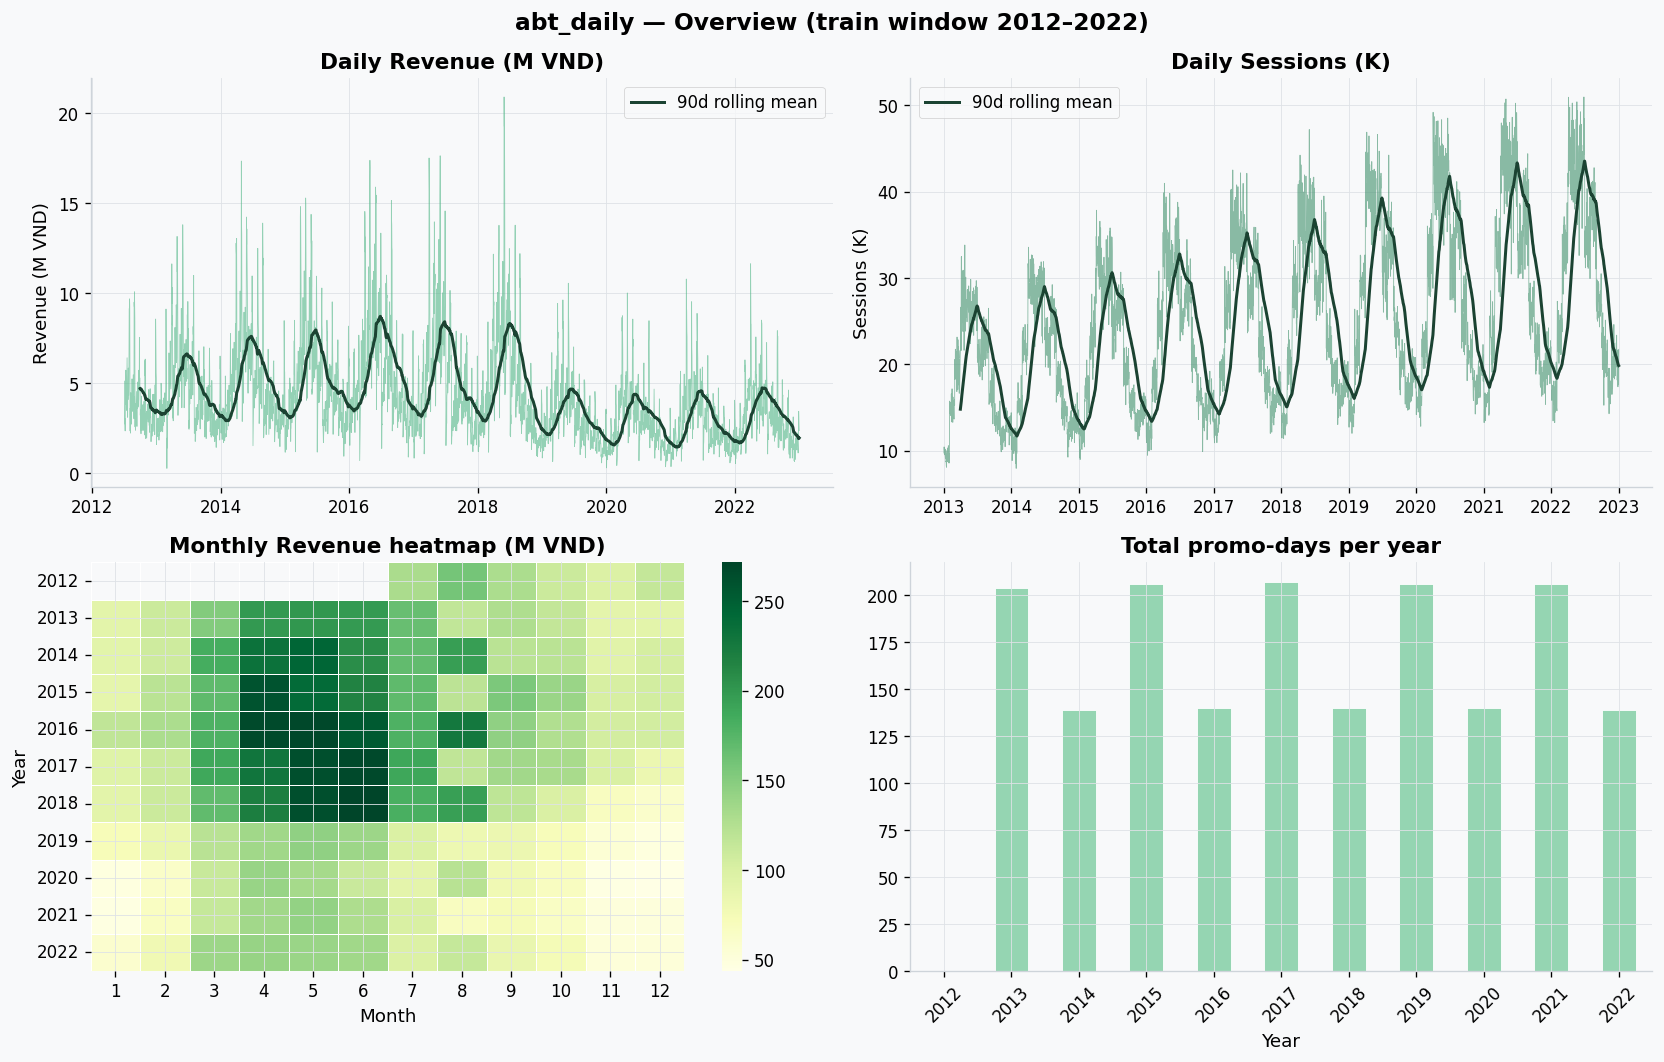

Saved → reports/fig_abt_daily_overview.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("abt_daily — Overview (train window 2012–2022)", fontsize=14, fontweight="bold")

train = abt_daily[abt_daily["date"] <= TRAIN_CUTOFF].copy()

# Revenue trend
ax = axes[0, 0]
ax.plot(train["date"], train["Revenue"] / 1e6, color="#52b788", lw=0.5, alpha=0.6)
roll = train.set_index("date")["Revenue"].rolling(90).mean() / 1e6
ax.plot(roll, color="#1b4332", lw=1.8, label="90d rolling mean")
ax.set_title("Daily Revenue (M VND)")
ax.set_ylabel("Revenue (M VND)")
ax.legend()

# Sessions trend
ax = axes[0, 1]
ax.plot(train["date"], train["sessions_total"] / 1e3, color="#40916c", lw=0.5, alpha=0.6)
roll_s = train.set_index("date")["sessions_total"].rolling(90).mean() / 1e3
ax.plot(roll_s, color="#1b4332", lw=1.8, label="90d rolling mean")
ax.set_title("Daily Sessions (K)")
ax.set_ylabel("Sessions (K)")
ax.legend()

# Monthly revenue heatmap (year × month)
train["year"] = train["date"].dt.year
train["month"] = train["date"].dt.month
monthly = train.pivot_table(index="year", columns="month", values="Revenue", aggfunc="sum") / 1e6
import seaborn as sns
sns.heatmap(monthly, ax=axes[1, 0], cmap="YlGn", fmt=".0f", annot=False, linewidths=0.3)
axes[1, 0].set_title("Monthly Revenue heatmap (M VND)")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Year")

# Active promos per year
promo_yr = train.groupby("year")["n_active_promos"].sum()
promo_yr.plot(kind="bar", ax=axes[1, 1], color="#95d5b2", edgecolor="white")
axes[1, 1].set_title("Total promo-days per year")
axes[1, 1].set_xlabel("Year")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(ROOT / "reports" / "fig_abt_daily_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → reports/fig_abt_daily_overview.png")


In [8]:
# Save ABT 1
out_path = PROCESSED / "abt_daily.parquet"
abt_daily.to_parquet(out_path, index=False, engine="pyarrow")
print(f"✅ Saved abt_daily.parquet — {abt_daily.shape[0]:,} rows × {abt_daily.shape[1]} cols")
print(f"   File size: {out_path.stat().st_size / 1e6:.1f} MB")


✅ Saved abt_daily.parquet — 4,381 rows × 38 cols
   File size: 0.3 MB


## 6. ABT 2 — `abt_orders_enriched.parquet`

Grain: 1 row / order_item. 5-way join: order_items × orders × products × customers × geography.


In [9]:
print("Building abt_orders_enriched (5-way join) ...")

abt_orders = sj.build_orders_enriched(
    order_items=order_items,
    orders=orders,
    products=products,
    customers=customers,
    geography=geography,
    returns=returns,
    reviews=reviews,
    shipments=shipments,
)

print(f"\nabt_orders_enriched shape: {abt_orders.shape}")
print(f"  Date range: {abt_orders['order_date'].min().date()} → {abt_orders['order_date'].max().date()}")
print(f"  Returned items: {abt_orders['is_returned'].sum():,} ({abt_orders['is_returned'].mean()*100:.1f}%)")
print(f"  Items with review: {abt_orders['has_review'].sum():,} ({abt_orders['has_review'].mean()*100:.1f}%)")
print(f"  Null geography: {abt_orders['region'].isnull().sum():,} rows")

# Leakage check
assert (abt_orders["order_date"] <= TRAIN_CUTOFF).all(), "LEAKAGE: post-cutoff orders in ABT!"
print(f"\n  Leakage check: ✅ all order_dates ≤ {TRAIN_CUTOFF.date()}")

abt_orders.head(2)


Building abt_orders_enriched (5-way join) ...

abt_orders_enriched shape: (714669, 39)
  Date range: 2012-07-04 → 2022-12-31
  Returned items: 39,946 (5.6%)
  Items with review: 113,553 (15.9%)
  Null geography: 0 rows

  Leakage check: ✅ all order_dates ≤ 2022-12-31


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,gross_revenue,net_revenue,discount_exceeds_gross,...,acquisition_channel,signup_date,city,region,district,item_margin,is_returned,delivery_days,rating,has_review
0,1,2400,7,1138.219971,0.0,NaN,NaN,7967.540039,7967.540039,False,...,social_media,2020-06-06,Hanoi,East,District #02,590.954102,False,4.0,5.0,True
1,2,609,7,10166.250000,0.0,NaN,NaN,71163.750000,71163.750000,False,...,social_media,2021-11-03,Phu Ly,East,District #02,8249.820312,True,4.0,NaN,False


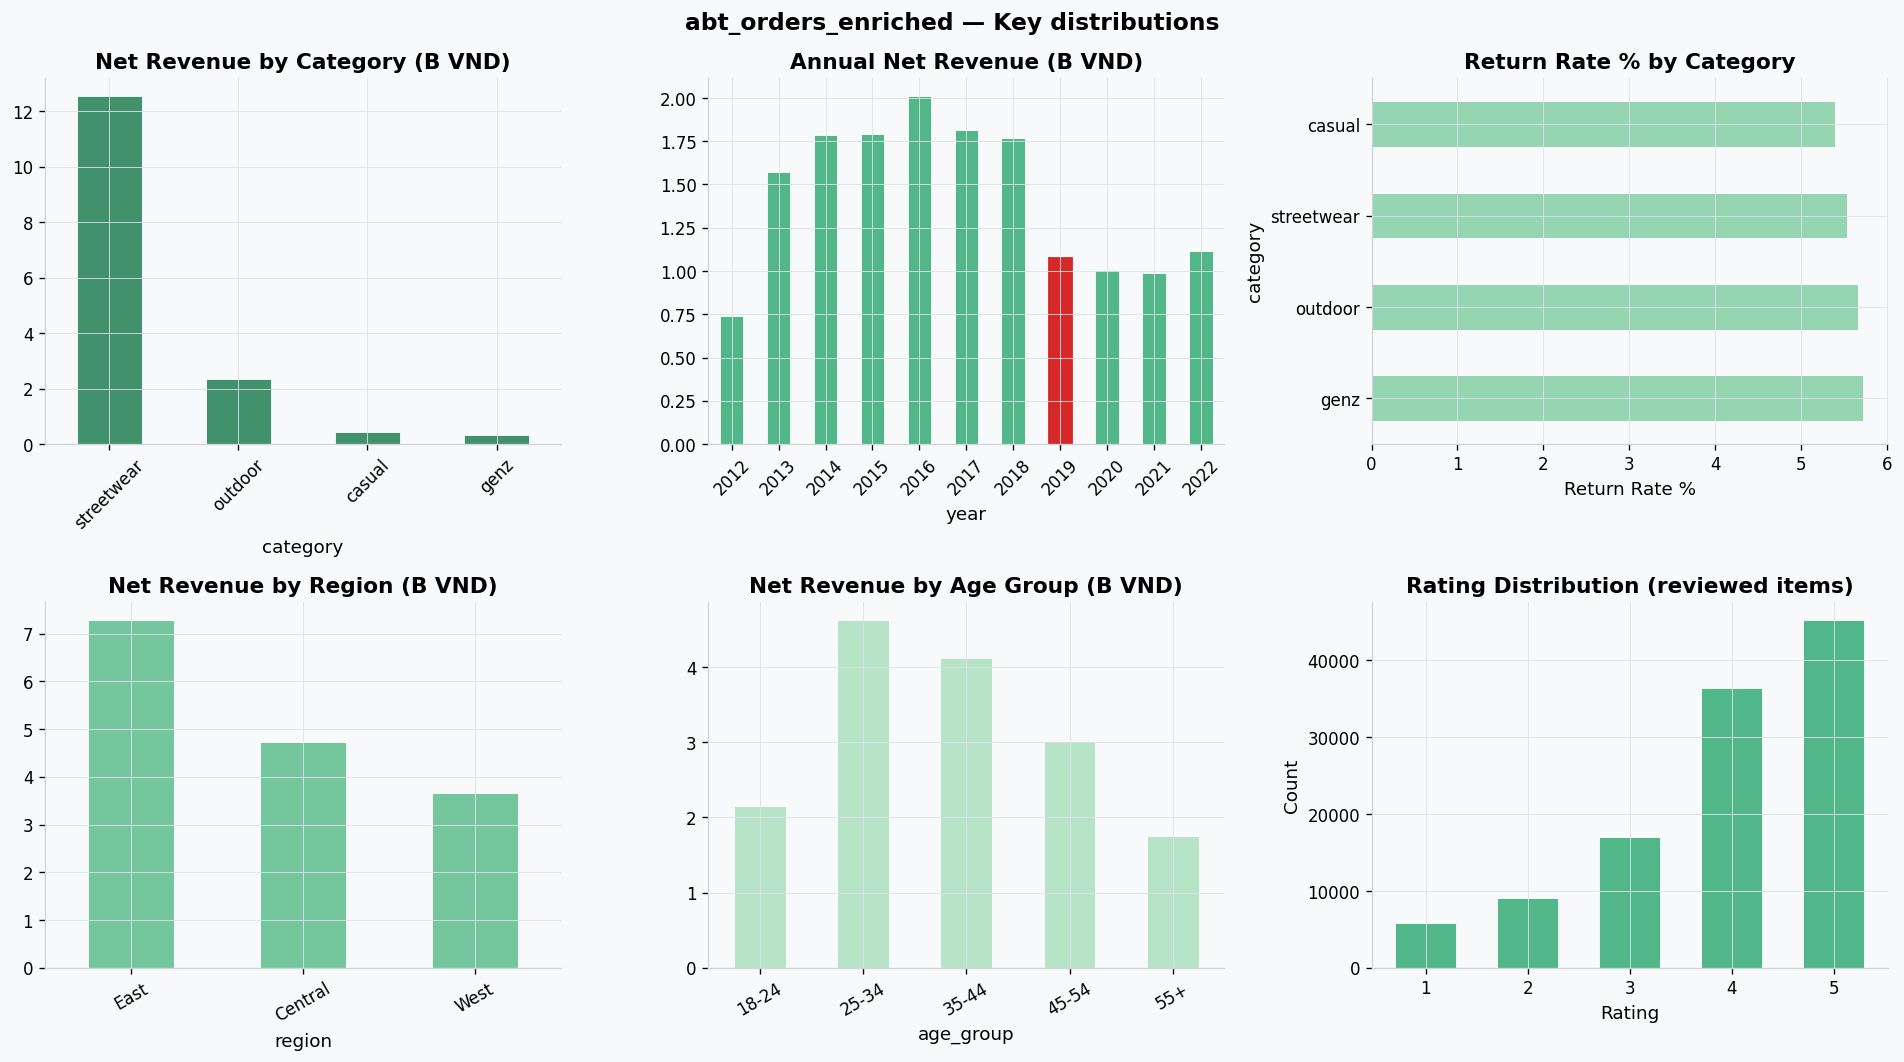

Saved → reports/fig_abt_orders_dist.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("abt_orders_enriched — Key distributions", fontsize=14, fontweight="bold")

# Revenue by category
cat_rev = abt_orders.groupby("category")["net_revenue"].sum().sort_values(ascending=False) / 1e9
cat_rev.plot(kind="bar", ax=axes[0, 0], color="#40916c", edgecolor="white")
axes[0, 0].set_title("Net Revenue by Category (B VND)")
axes[0, 0].tick_params(axis="x", rotation=45)

# Revenue by year
abt_orders["year"] = abt_orders["order_date"].dt.year
yr_rev = abt_orders.groupby("year")["net_revenue"].sum() / 1e9
yr_rev.plot(kind="bar", ax=axes[0, 1], color="#52b788", edgecolor="white")
axes[0, 1].set_title("Annual Net Revenue (B VND)")
axes[0, 1].tick_params(axis="x", rotation=45)
# Highlight 2019
bars = axes[0, 1].patches
yr_list = list(yr_rev.index)
if 2019 in yr_list:
    bars[yr_list.index(2019)].set_color("#d62828")

# Return rate by category
ret_rate = abt_orders.groupby("category")["is_returned"].mean().sort_values(ascending=False) * 100
ret_rate.plot(kind="barh", ax=axes[0, 2], color="#95d5b2", edgecolor="white")
axes[0, 2].set_title("Return Rate % by Category")
axes[0, 2].set_xlabel("Return Rate %")

# Revenue by region
reg_rev = abt_orders.groupby("region")["net_revenue"].sum().sort_values(ascending=False) / 1e9
reg_rev.plot(kind="bar", ax=axes[1, 0], color="#74c69d", edgecolor="white")
axes[1, 0].set_title("Net Revenue by Region (B VND)")
axes[1, 0].tick_params(axis="x", rotation=30)

# Revenue by age group
age_order = ["18-24","25-34","35-44","45-54","55+"]
age_rev = abt_orders.groupby("age_group")["net_revenue"].sum().reindex(age_order) / 1e9
age_rev.plot(kind="bar", ax=axes[1, 1], color="#b7e4c7", edgecolor="white")
axes[1, 1].set_title("Net Revenue by Age Group (B VND)")
axes[1, 1].tick_params(axis="x", rotation=30)

# Rating distribution
rating_counts = abt_orders["rating"].dropna().value_counts().sort_index()
axes[1, 2].bar(rating_counts.index, rating_counts.values, color="#52b788", edgecolor="white", width=0.6)
axes[1, 2].set_title("Rating Distribution (reviewed items)")
axes[1, 2].set_xlabel("Rating")
axes[1, 2].set_ylabel("Count")

plt.tight_layout()
plt.savefig(ROOT / "reports" / "fig_abt_orders_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → reports/fig_abt_orders_dist.png")


In [11]:
# Save ABT 2 (partitioned by year for faster loading)
abt_orders["year"] = abt_orders["order_date"].dt.year
out_path = PROCESSED / "abt_orders_enriched.parquet"
abt_orders.to_parquet(out_path, index=False, engine="pyarrow",
                      partition_cols=["year"])
print(f"✅ Saved abt_orders_enriched.parquet (partitioned by year)")
print(f"   Total rows: {abt_orders.shape[0]:,}  |  Cols: {abt_orders.shape[1]}")


✅ Saved abt_orders_enriched.parquet (partitioned by year)
   Total rows: 714,669  |  Cols: 40


## 7. ABT 3 — `abt_customer_cohort.parquet`

Grain: 1 row / (customer_id, months_since_signup). For Story 3 retention analysis.


In [12]:
print("Building abt_customer_cohort ...")

abt_cohort = sj.build_customer_cohort(
    orders=orders,
    order_items=order_items,
    customers=customers,
)

print(f"\nabt_customer_cohort shape: {abt_cohort.shape}")
print(f"  Unique customers  : {abt_cohort['customer_id'].nunique():,}")
print(f"  Unique cohort months: {abt_cohort['signup_month'].nunique()}")
print(f"  months_since_signup range: {abt_cohort['months_since_signup'].min()} → {abt_cohort['months_since_signup'].max()}")

abt_cohort.head(3)


Building abt_customer_cohort ...

abt_customer_cohort shape: (158696, 8)
  Unique customers  : 49,069
  Unique cohort months: 132
  months_since_signup range: 0 → 130


,customer_id,signup_month,months_since_signup,acquisition_channel,orders_in_month,revenue_in_month,cum_revenue,is_active
0,2,2013-12,11,email_campaign,1,65362.257812,65362.257812,True
1,2,2013-12,103,email_campaign,1,59996.554688,125358.812500,True
2,4,2017-11,31,referral,1,10939.060547,10939.060547,True


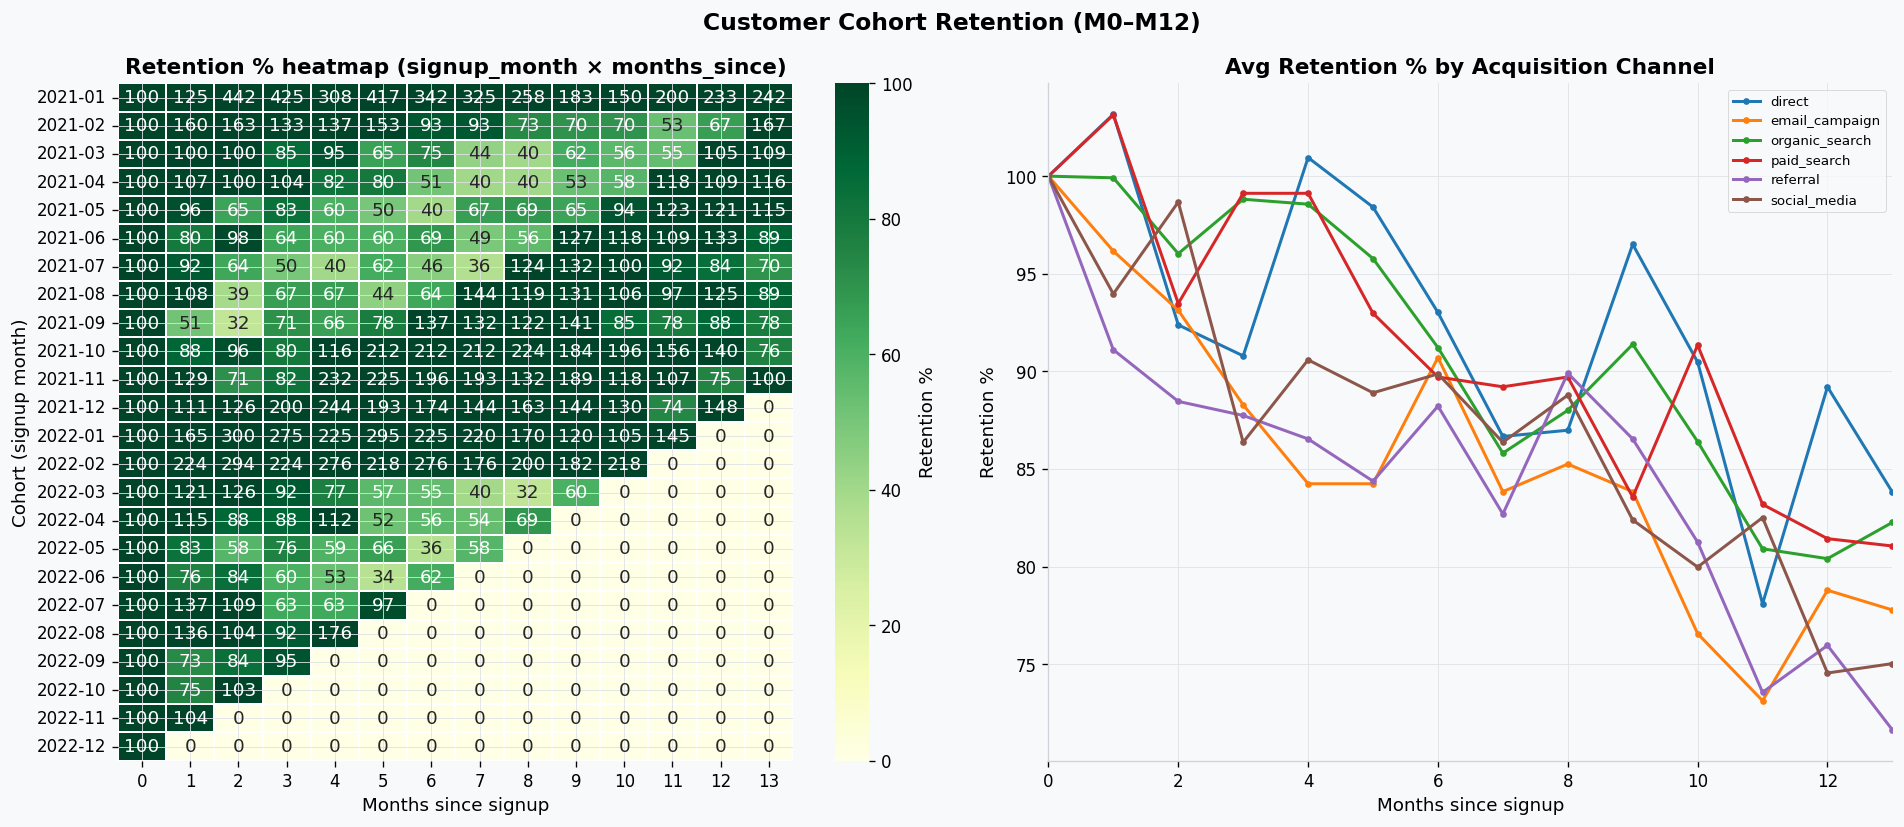

Saved → reports/fig_cohort_retention.png


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cohort retention heatmap (M0-M12)
max_months = 13
cohort_sub = abt_cohort[abt_cohort["months_since_signup"] <= max_months].copy()

retention = cohort_sub.groupby(["signup_month", "months_since_signup"])["customer_id"].nunique().unstack(fill_value=0)
cohort_size = retention[0] if 0 in retention.columns else retention.iloc[:, 0]
retention_rate = retention.div(cohort_size, axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Customer Cohort Retention (M0–M12)", fontsize=14, fontweight="bold")

# Heatmap (last 24 cohort months for readability)
heatmap_data = retention_rate.tail(24)
sns.heatmap(
    heatmap_data, ax=axes[0], cmap="YlGn", fmt=".0f",
    annot=(heatmap_data.shape[0] <= 24),
    linewidths=0.2, vmin=0, vmax=100,
    cbar_kws={"label": "Retention %"},
)
axes[0].set_title("Retention % heatmap (signup_month × months_since)")
axes[0].set_xlabel("Months since signup")
axes[0].set_ylabel("Cohort (signup month)")

# Average retention curve per acquisition_channel
ch_retention = (
    cohort_sub.groupby(["acquisition_channel", "months_since_signup"])["customer_id"]
    .nunique()
    .reset_index(name="active_customers")
)
m0 = ch_retention[ch_retention["months_since_signup"] == 0].rename(
    columns={"active_customers": "cohort_size"}
)[["acquisition_channel", "cohort_size"]]
ch_retention = ch_retention.merge(m0, on="acquisition_channel", how="left")
ch_retention["retention_pct"] = ch_retention["active_customers"] / ch_retention["cohort_size"] * 100

for ch, grp in ch_retention.groupby("acquisition_channel"):
    grp = grp.sort_values("months_since_signup")
    axes[1].plot(grp["months_since_signup"], grp["retention_pct"], marker="o", ms=3, label=ch)
axes[1].set_title("Avg Retention % by Acquisition Channel")
axes[1].set_xlabel("Months since signup")
axes[1].set_ylabel("Retention %")
axes[1].legend(fontsize=8, loc="upper right")
axes[1].set_xlim(0, max_months)

plt.tight_layout()
plt.savefig(ROOT / "reports" / "fig_cohort_retention.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → reports/fig_cohort_retention.png")


In [14]:
# Save ABT 3
out_path = PROCESSED / "abt_customer_cohort.parquet"
abt_cohort.to_parquet(out_path, index=False, engine="pyarrow")
print(f"✅ Saved abt_customer_cohort.parquet — {abt_cohort.shape[0]:,} rows × {abt_cohort.shape[1]} cols")
print(f"   File size: {out_path.stat().st_size / 1e6:.1f} MB")


✅ Saved abt_customer_cohort.parquet — 158,696 rows × 8 cols
   File size: 2.7 MB


## 8. Quality Gates (eda_plan.md §8)

Checklist tự động — phải pass hết trước khi sang Part 3 modelling.


In [15]:
print("=" * 60)
print("QUALITY GATE CHECKS")
print("=" * 60)

failures = []

def check(condition: bool, label: str, detail: str = ""):
    icon = "✅" if condition else "❌"
    msg = f"  {icon} {label}"
    if not condition and detail:
        msg += f" — {detail}"
    print(msg)
    if not condition:
        failures.append(label)

# [1] abt_daily row count (2012-07-04 → 2024-07-01 inclusive)
expected_rows = len(pd.date_range("2012-07-04", "2024-07-01", freq="D"))
check(len(abt_daily) == expected_rows,
      f"abt_daily has {expected_rows:,} rows",
      f"actual={len(abt_daily):,}")

# [2] Revenue/COGS NaN for test window
test_rev_ok = abt_daily.loc[abt_daily["date"] > TRAIN_CUTOFF, "Revenue"].isna().all()
check(test_rev_ok, "Revenue = NaN for all dates > 2022-12-31")

# [3] No order_date > cutoff in abt_orders
max_order_date = abt_orders["order_date"].max()
check(max_order_date <= TRAIN_CUTOFF,
      f"abt_orders max order_date ≤ {TRAIN_CUTOFF.date()}",
      f"actual max={max_order_date.date()}")

# [4] abt_orders grain check (no exact duplicates on order_id+product_id is hard — check shape)
check(len(abt_orders) > 700_000,
      f"abt_orders has >700K rows (expected ~714K)",
      f"actual={len(abt_orders):,}")

# [5] abt_cohort months_since_signup >= 0
check((abt_cohort["months_since_signup"] >= 0).all(),
      "abt_cohort months_since_signup all >= 0")

# [6] No feature pulls from web_traffic live cols (already aggregated to daily)
check("sessions" not in abt_daily.columns,
      "abt_daily has no raw 'sessions' col (daily agg used instead)")

# [7] Promo calendar covers full date range
check(len(promo_daily) == len(FULL_RANGE),
      f"promo_daily covers full {len(FULL_RANGE):,} days")

# [8] Idempotency — re-load and compare shape
abt_daily_reload = pd.read_parquet(PROCESSED / "abt_daily.parquet", engine="pyarrow")
check(abt_daily_reload.shape == abt_daily.shape,
      "abt_daily.parquet re-load shape matches in-memory")

print()
if failures:
    print(f"❌ {len(failures)} gate(s) FAILED: {failures}")
else:
    print("✅ ALL quality gates PASSED — safe to proceed to modelling / visualization")


QUALITY GATE CHECKS
  ✅ abt_daily has 4,381 rows
  ✅ Revenue = NaN for all dates > 2022-12-31
  ✅ abt_orders max order_date ≤ 2022-12-31
  ✅ abt_orders has >700K rows (expected ~714K)
  ✅ abt_cohort months_since_signup all >= 0
  ✅ abt_daily has no raw 'sessions' col (daily agg used instead)
  ✅ promo_daily covers full 4,381 days
  ✅ abt_daily.parquet re-load shape matches in-memory

✅ ALL quality gates PASSED — safe to proceed to modelling / visualization


## 9. Summary — Phase 2 & 3 Complete

| Deliverable | Path | Status |
|---|---|---|
| Cleaned interim tables | `data/interim/*.parquet` | ✅ |
| `abt_daily.parquet` | `data/processed/` | ✅ |
| `abt_orders_enriched.parquet` | `data/processed/` | ✅ |
| `abt_customer_cohort.parquet` | `data/processed/` | ✅ |
| `src/io.py`, `src/cleaning.py` | `src/` | ✅ |
| `src/joining.py` | `src/` | ✅ |
| `src/features/calendar.py` | `src/features/` | ✅ |
| `src/viz/style.py` | `src/viz/` | ✅ |

### Bước tiếp theo

```
Phase 4 → notebooks/01_eda_exploratory.ipynb   (verify 6 context facts + 7 hypotheses)
Phase 5 → notebooks/30_forecasting.ipynb        (feature engineering + model)
Phase 6 → notebooks/21_story_*.ipynb            (Part 2 stories)
```


## 10. Customer LTV Proxies & RFM Features

Building customer-level behavioral features for Story 3 analysis and for understanding retention quality differences across acquisition channels.


In [ ]:
print("=" * 65)
print("SECTION 10: CUSTOMER LTV PROXIES + RFM FEATURES")
print("=" * 65)

# ── 10.1 RFM computation (as of TRAIN_CUTOFF — leakage safe)
# Input: abt_orders_enriched (already loaded as abt_orders)
abt_orders_rfm = pd.read_parquet(PROCESSED / "abt_orders_enriched.parquet")

# Order-level summary per customer
order_level = (
    abt_orders_rfm.groupby(["customer_id","order_id","order_date"])["net_revenue"]
    .sum().reset_index(name="order_revenue")
)

rfm = order_level.groupby("customer_id").agg(
    last_order_date=("order_date","max"),
    n_orders=("order_id","nunique"),
    total_revenue=("order_revenue","sum"),
    avg_order_value=("order_revenue","mean"),
    min_order_value=("order_revenue","min"),
    max_order_value=("order_revenue","max"),
).reset_index()

# Recency: days since last order as of TRAIN_CUTOFF
rfm["recency_days"] = (TRAIN_CUTOFF - rfm["last_order_date"]).dt.days

# RFM segments (simple quintile-based)
rfm["R_score"] = pd.qcut(rfm["recency_days"], q=5, labels=[5,4,3,2,1]).astype(int)  # 5=most recent
rfm["F_score"] = pd.qcut(rfm["n_orders"].clip(upper=rfm["n_orders"].quantile(0.99)),
                          q=5, labels=[1,2,3,4,5], duplicates="drop").astype(int)
rfm["M_score"] = pd.qcut(rfm["total_revenue"].clip(upper=rfm["total_revenue"].quantile(0.99)),
                          q=5, labels=[1,2,3,4,5], duplicates="drop").astype(int)
rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

# Customer segments based on RFM
def rfm_segment(row):
    if row["RFM_score"] >= 13:
        return "Champion"
    elif row["RFM_score"] >= 10:
        return "Loyal"
    elif row["R_score"] >= 4:
        return "New/Promising"
    elif row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At Risk"
    else:
        return "Lost/Inactive"

rfm["segment"] = rfm.apply(rfm_segment, axis=1)

print("\nRFM Summary:")
print(rfm[["recency_days","n_orders","total_revenue","avg_order_value","RFM_score"]].describe().round(1).to_string())
print("\nCustomer segments:")
print(rfm["segment"].value_counts().to_string())
print(f"\nTotal unique customers in RFM: {len(rfm):,}")

# ── 10.2 LTV proxies: M3, M6, M12 cumulative revenue
# From abt_cohort: cumulative revenue at M3, M6, M12 milestones
abt_cohort_ltv = pd.read_parquet(PROCESSED / "abt_customer_cohort.parquet")

ltv_milestones = {}
for m in [3, 6, 12, 24]:
    milestone = abt_cohort_ltv[abt_cohort_ltv["months_since_signup"] == m][["customer_id","cum_revenue"]].rename(
        columns={"cum_revenue": f"ltv_m{m}"}
    )
    ltv_milestones[m] = milestone

# Build LTV table
ltv_table = abt_cohort_ltv[["customer_id","acquisition_channel"]].drop_duplicates("customer_id")
for m, df in ltv_milestones.items():
    ltv_table = ltv_table.merge(df, on="customer_id", how="left")

# Merge with RFM
rfm_full = rfm.merge(ltv_table, on="customer_id", how="left")

print(f"\nLTV at milestones (M3, M6, M12, M24) — mean by acquisition channel:")
ltv_by_ch = rfm_full.groupby("acquisition_channel")[["ltv_m3","ltv_m6","ltv_m12","ltv_m24"]].mean()
print(ltv_by_ch.round(0).to_string())

# ── 10.3 Channel efficiency: LTV / cohort size (revenue per acquired customer)
cohort_size_by_ch = abt_cohort_ltv[abt_cohort_ltv["months_since_signup"]==0].groupby("acquisition_channel")["customer_id"].nunique()
ltv_m12_by_ch = rfm_full.groupby("acquisition_channel")["ltv_m12"].mean()
ch_efficiency = pd.DataFrame({
    "cohort_size": cohort_size_by_ch,
    "avg_ltv_m12": ltv_m12_by_ch,
}).dropna()
ch_efficiency["ltv_per_acquired"] = ch_efficiency["avg_ltv_m12"]  # already per customer
ch_efficiency = ch_efficiency.sort_values("avg_ltv_m12", ascending=False)
print("\nChannel efficiency (LTV M12 per acquired customer):")
print(ch_efficiency.round(0).to_string())

# ── Save RFM table
rfm_path = PROCESSED / "abt_rfm.parquet"
rfm_full.to_parquet(rfm_path, index=False, engine="pyarrow")
print(f"\n✅ Saved abt_rfm.parquet — {rfm_full.shape[0]:,} rows × {rfm_full.shape[1]} cols")

# ── Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Customer LTV & RFM Analysis", fontsize=13, fontweight="bold")

# Plot 1: RFM segment distribution
seg_counts = rfm["segment"].value_counts()
colors_seg = {"Champion":"#1b4332","Loyal":"#2d6a4f","New/Promising":"#52b788",
              "At Risk":"#f4a261","Lost/Inactive":"#d62828"}
seg_colors_list = [colors_seg.get(s, "#adb5bd") for s in seg_counts.index]
axes[0].bar(seg_counts.index, seg_counts.values, color=seg_colors_list, edgecolor="white")
axes[0].set_title("Customer Segments (RFM)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_ylabel("Number of customers")
for i, (idx, val) in enumerate(seg_counts.items()):
    axes[0].text(i, val + 50, f"{val:,}", ha="center", fontsize=8)

# Plot 2: LTV by channel (M3, M6, M12)
if not ltv_by_ch.empty:
    ltv_display = ltv_by_ch[["ltv_m3","ltv_m6","ltv_m12"]].dropna(how="all")
    ltv_display.columns = ["M3", "M6", "M12"]
    ltv_display.plot(kind="bar", ax=axes[1], color=["#95d5b2","#52b788","#2d6a4f"], edgecolor="white")
    axes[1].set_title("Avg LTV by Acquisition Channel (M3, M6, M12)")
    axes[1].set_xlabel("Channel")
    axes[1].set_ylabel("Cumulative Revenue (VND)")
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].legend(title="Months since signup")

# Plot 3: Recency distribution by segment
for seg, color in colors_seg.items():
    subset = rfm[rfm["segment"] == seg]["recency_days"]
    if len(subset) > 0:
        axes[2].hist(subset, bins=30, alpha=0.5, color=color, label=seg)
axes[2].set_title("Recency Distribution by Segment")
axes[2].set_xlabel("Days since last order")
axes[2].set_ylabel("Count")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.savefig(ROOT / "reports" / "fig_rfm_ltv.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → reports/fig_rfm_ltv.png")


## 11. Inventory Pressure Signals, Demand-Supply Gap Features & Conversion Rate Features

Building operational features for the ABT that can be used in Part 3 forecasting and Part 2 Story 5.


In [ ]:
print("=" * 65)
print("SECTION 11: INVENTORY PRESSURE + DEMAND-SUPPLY + CONVERSION FEATURES")
print("=" * 65)

from src import io as sio
inv_raw = sio.load_inventory()
from src.cleaning import clean_inventory
inv_clean = clean_inventory(inv_raw) if hasattr(__import__('src.cleaning', fromlist=['clean_inventory']), 'clean_inventory') else inv_raw.copy()

# Normalize snapshot_date
inv_clean["snapshot_date"] = pd.to_datetime(inv_clean["snapshot_date"])
inv_clean["year"]  = inv_clean["snapshot_date"].dt.year
inv_clean["month"] = inv_clean["snapshot_date"].dt.month

print(f"Inventory loaded: {inv_clean.shape[0]:,} rows")

# ── 11.1 Monthly inventory aggregates (input to Part 3 features)
inv_monthly = inv_clean.groupby("snapshot_date").agg(
    total_stock_on_hand=("stock_on_hand","sum"),
    total_units_received=("units_received","sum"),
    total_units_sold=("units_sold","sum"),
    total_stockout_days=("stockout_days","sum"),
    mean_days_of_supply=("days_of_supply","mean"),
    mean_fill_rate=("fill_rate","mean"),
    pct_stockout_products=("stockout_flag","mean"),
    pct_overstock_products=("overstock_flag","mean"),
    pct_reorder_products=("reorder_flag","mean"),
    mean_sell_through=("sell_through_rate","mean"),
    n_products=("product_id","nunique"),
).reset_index()

# ── 11.2 Demand-supply gap features
inv_monthly["demand_supply_ratio"] = (
    inv_monthly["total_units_sold"] /
    (inv_monthly["total_units_received"] + inv_monthly["total_units_sold"] + 1e-9)
)  # high ratio = demand >> supply

inv_monthly["stockout_pressure"] = (
    inv_monthly["total_stockout_days"] / inv_monthly["n_products"]
)  # avg stockout days per product per month — higher = more pressure

inv_monthly["overstock_ratio"] = inv_monthly["pct_overstock_products"] / (inv_monthly["pct_stockout_products"] + 0.01)
# > 1: more overstock than stockout → excess inventory; < 1: more stockout than overstock

inv_monthly["inventory_efficiency"] = inv_monthly["mean_sell_through"] * inv_monthly["mean_fill_rate"]
# Combined score: high = sells quickly AND stays in stock

print("\nInventory monthly features shape:", inv_monthly.shape)
print(inv_monthly[["snapshot_date","pct_stockout_products","pct_overstock_products",
                    "demand_supply_ratio","stockout_pressure","inventory_efficiency"]].tail(6).round(3).to_string(index=False))

# ── 11.3 Merge inventory monthly features into abt_daily (with 28-day lag — leakage safe)
abt_daily_updated = pd.read_parquet(PROCESSED / "abt_daily.parquet")
abt_daily_updated["date"] = pd.to_datetime(abt_daily_updated["date"])

# For each date, find the most recent inventory snapshot that is at least 28 days old
inv_monthly_sorted = inv_monthly.sort_values("snapshot_date").reset_index(drop=True)

def get_lagged_inv(date, lag_days=28):
    """Get inventory snapshot from at least lag_days before this date."""
    cutoff = date - pd.Timedelta(days=lag_days)
    valid = inv_monthly_sorted[inv_monthly_sorted["snapshot_date"] <= cutoff]
    if len(valid) == 0:
        return None
    return valid.iloc[-1]

# Vectorized: use merge_asof (sorted by date)
inv_for_merge = inv_monthly_sorted[["snapshot_date","pct_stockout_products","pct_overstock_products",
                                     "demand_supply_ratio","stockout_pressure","mean_fill_rate",
                                     "mean_days_of_supply","inventory_efficiency","mean_sell_through"]].copy()

# Shift snapshot_date by 28 days forward to get the earliest date we can use this snapshot
inv_for_merge["available_from"] = inv_for_merge["snapshot_date"] + pd.Timedelta(days=28)

abt_daily_updated = pd.merge_asof(
    abt_daily_updated.sort_values("date"),
    inv_for_merge.rename(columns=lambda c: f"inv_{c}" if c not in ["snapshot_date","available_from"] else c)
              .drop(columns=["snapshot_date"])
              .rename(columns={"available_from":"date"})
              .sort_values("date"),
    on="date",
    direction="backward",
)
# Rename back to avoid confusion
inv_cols = [c for c in abt_daily_updated.columns if c.startswith("inv_")]
print(f"\nAdded {len(inv_cols)} inventory pressure features to abt_daily:")
print(inv_cols)

# ── 11.4 Conversion rate features at multiple funnel stages
# These are historical (lagged) features only — safe for forecasting
abt_daily_updated["conversion_orders_sessions"] = (
    abt_daily_updated["n_orders"] / (abt_daily_updated["sessions_total"] + 1e-9)
)
abt_daily_updated["conversion_delivered_orders"] = (
    abt_daily_updated["n_delivered"] / (abt_daily_updated["n_orders"] + 1e-9)
)

# Rolling conversion rate (30-day, shifted by 28 to avoid leakage)
abt_daily_updated = abt_daily_updated.sort_values("date").reset_index(drop=True)
for window in [30, 90]:
    col = f"conv_sessions_orders_roll{window}"
    abt_daily_updated[col] = (
        abt_daily_updated["conversion_orders_sessions"]
        .shift(28)
        .rolling(window, min_periods=window//2)
        .mean()
    )

# Drop raw conversion cols (not safe to use directly — leak from future orders)
abt_daily_updated.drop(columns=["conversion_orders_sessions","conversion_delivered_orders"], inplace=True)

print(f"\nConversion rate rolling features added: conv_sessions_orders_roll30, conv_sessions_orders_roll90")

# ── Save updated abt_daily
out_path = PROCESSED / "abt_daily.parquet"
abt_daily_updated.to_parquet(out_path, index=False, engine="pyarrow")
print(f"\n✅ Saved updated abt_daily.parquet — {abt_daily_updated.shape[0]:,} rows × {abt_daily_updated.shape[1]} cols")
print(f"   New columns added: {len(inv_cols) + 2} (inventory pressure + conversion features)")

# ── Save inventory monthly features separately for Story 5
inv_monthly_path = PROCESSED / "abt_inventory_monthly.parquet"
inv_monthly.to_parquet(inv_monthly_path, index=False, engine="pyarrow")
print(f"✅ Saved abt_inventory_monthly.parquet — {inv_monthly.shape[0]:,} rows × {inv_monthly.shape[1]} cols")


## 12. Label Leakage Audit

Critical check before any modelling: ensure no future information has contaminated any feature in `abt_daily`.


In [ ]:
print("=" * 65)
print("SECTION 12: LABEL LEAKAGE AUDIT")
print("=" * 65)

# Load the final abt_daily
final_abt = pd.read_parquet(PROCESSED / "abt_daily.parquet")
final_abt["date"] = pd.to_datetime(final_abt["date"])

test_mask = final_abt["date"] > TRAIN_CUTOFF
train_mask = ~test_mask

print(f"\nDataset overview:")
print(f"  Total rows: {len(final_abt):,}")
print(f"  Train rows (≤2022-12-31): {train_mask.sum():,}")
print(f"  Test rows (>2022-12-31):  {test_mask.sum():,}")

# ── Check 1: Revenue and COGS must be NaN for test window
LEAKAGE_COLS = ["Revenue", "COGS"]
leakage_failures = []

for col in LEAKAGE_COLS:
    if col in final_abt.columns:
        n_non_nan_test = final_abt.loc[test_mask, col].notna().sum()
        status = "✅ CLEAN" if n_non_nan_test == 0 else f"❌ LEAKAGE: {n_non_nan_test} non-NaN rows in test"
        print(f"  [{col}] test window: {status}")
        if n_non_nan_test > 0:
            leakage_failures.append(col)

# ── Check 2: Transaction-derived columns must also be NaN in test window
# These are columns that come from orders/order_items which only go to 2022-12-31
TRANSACTION_DERIVED = ["n_orders","n_delivered","n_cancelled","n_returned","n_items",
                        "total_quantity","gross_revenue_recon","discount_amount_sum"]

for col in TRANSACTION_DERIVED:
    if col in final_abt.columns:
        n_non_nan_test = final_abt.loc[test_mask, col].notna().sum()
        status = "✅ CLEAN" if n_non_nan_test == 0 else f"⚠️ {n_non_nan_test} non-NaN test rows"
        print(f"  [{col}] test window: {status}")
        if n_non_nan_test > 0 and col in ["n_orders","n_delivered"]:
            leakage_failures.append(col)

# ── Check 3: Calendar features are complete for full date range (safe to have in test)
CALENDAR_COLS = ["month", "dow", "doy", "quarter", "year", "is_weekend",
                 "is_tet_window", "days_to_tet", "is_fixed_holiday", "days_since_start"]
print("\nCalendar features completeness (must be non-null for ALL rows including test):")
for col in CALENDAR_COLS:
    if col in final_abt.columns:
        n_null = final_abt[col].isna().sum()
        status = "✅" if n_null == 0 else f"❌ {n_null} nulls"
        print(f"  [{col}]: {status}")

# ── Check 4: Promo features must cover test window (calendar known in advance)
PROMO_COLS = ["n_active_promos","max_discount_active","days_to_next_promo","any_pct_promo"]
print("\nPromo features coverage in test window (must be non-null — calendar known):")
for col in PROMO_COLS:
    if col in final_abt.columns:
        n_null_test = final_abt.loc[test_mask, col].isna().sum()
        status = "✅" if n_null_test == 0 else f"⚠️ {n_null_test} nulls in test"
        print(f"  [{col}] test: {status}")

# ── Check 5: No future-looking lag features (all lag≥28 rule)
# The naming convention: rev_lag_28, rev_lag_91, etc.
lag_cols = [c for c in final_abt.columns if "lag" in c.lower()]
print(f"\nLag-based features found: {lag_cols}")
# These are computed at modelling time (not in ABT), but check if any appear
if lag_cols:
    print("  Warning: lag features in ABT may be precomputed — verify shift≥28 was applied")

# ── Check 6: Correlation test — are any features suspiciously correlated with future Revenue?
# High correlation on test window features with lagged Revenue from train = potential leakage
print("\n=== CORRELATION LEAKAGE SCREEN ===")
train_data = final_abt[train_mask].copy()
potential_leak_cols = [c for c in final_abt.columns
                       if c not in ["date","Revenue","COGS"] + lag_cols
                       and not any(x in c for x in ["lag","roll","inv_"])]
if "Revenue" in train_data.columns:
    rev_corrs = {}
    for col in potential_leak_cols[:20]:  # check top 20 non-lag features
        try:
            corr = train_data[col].corr(train_data["Revenue"])
            if abs(corr) > 0.8:
                rev_corrs[col] = corr
        except Exception:
            pass
    if rev_corrs:
        print("Features with suspiciously high correlation to Revenue (>0.8):")
        for col, corr in sorted(rev_corrs.items(), key=lambda x: -abs(x[1])):
            print(f"  {col}: {corr:.3f} — INVESTIGATE for leakage")
    else:
        print("  No suspiciously high correlations found in non-lag features.")

# ── Final verdict
print("\n" + "="*65)
if not leakage_failures:
    print("✅ LEAKAGE AUDIT PASSED — all critical columns clean")
    print("   Safe to proceed to Part 3 modelling (30_forecasting.ipynb)")
else:
    print(f"❌ LEAKAGE AUDIT FAILED — {len(leakage_failures)} column(s) need fixing:")
    for col in leakage_failures:
        print(f"   - {col}: non-NaN values found in test window > 2022-12-31")
    print("   FIX: Ensure these columns are set to NaN for date > TRAIN_CUTOFF")
print("="*65)
